# IY021 - SimCLR Embeddings + SVM: Dual-Channel NEW Experimental Data

This notebook mirrors `IY021_test_simclr_exp_data_dual.ipynb`, but evaluates SimCLR checkpoints on the refactored `_NEW` experimental dataset:

`EXP-25-IY008/4_transformed_exp_time_series_NEW`

The `_NEW` folder contains broad TF/group files rather than the old six-class glucose/TF setup. The notebook therefore discovers paired mCherry/GFP files, normalises TF names to uppercase, selects the top TF classes by paired-cell count, balances them, then evaluates frozen SimCLR backbones with an RBF SVM downstream classifier.

In [1]:
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from tqdm.auto import tqdm


def find_project_root(start=None):
    """Find the repository root from either the repo or experiment directory."""
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "experiments").exists():
            return candidate
    raise RuntimeError("Could not find stochastic_simulations project root.")


PROJECT_ROOT = find_project_root()
EXP_DIR = PROJECT_ROOT / "experiments"
IY021_DIR = EXP_DIR / "EXP-26-IY021"
DATA_DIR = EXP_DIR / "EXP-25-IY008" / "4_transformed_exp_time_series_NEW"
SRC_DIR = PROJECT_ROOT / "src"
sys.path.insert(0, str(SRC_DIR.resolve()))

from models.ssl_transformer import SSL_Transformer

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
META_COLS = ["id", "group", "experiment"]
MIN_CELLS_PER_CLASS = 50
MAX_CLASSES = 12
TOP_N_CONFUSION = 6

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})
sns.set_theme(style="whitegrid", palette="colorblind")

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir exists: {DATA_DIR.exists()} -> {DATA_DIR}")
print(f"Device: {DEVICE}")

Project root: /home/ianyang/stochastic_simulations
Data dir exists: True -> /home/ianyang/stochastic_simulations/experiments/EXP-25-IY008/4_transformed_exp_time_series_NEW
Device: cuda


/home/ianyang/micromamba/envs/stochastic_sim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Discover Paired NEW Data and Assign TF Labels

In [2]:
def normalise_tf_name(group_name):
    """Remove channel prefixes and normalise TF names for cross-experiment grouping."""
    return re.sub(r"^ch\d+_", "", str(group_name)).upper()


def discover_paired_files(data_dir):
    """Find file stems that have both mCherry and GFP time-series CSVs."""
    if not data_dir.exists():
        raise FileNotFoundError(f"Missing data directory: {data_dir}")
    gfp = {p.stem.replace("_GFP_time_series", ""): p for p in data_dir.glob("*_GFP_time_series.csv")}
    mcherry = {p.stem.replace("_mCherry_time_series", ""): p for p in data_dir.glob("*_mCherry_time_series.csv")}
    paired_keys = sorted(set(gfp) & set(mcherry))
    rows = []
    for key in paired_keys:
        experiment = key.split("_group_")[0]
        group = key.split("_group_", 1)[1]
        rows.append({
            "key": key,
            "experiment": experiment,
            "group": group,
            "tf": normalise_tf_name(group),
            "mcherry_path": mcherry[key],
            "gfp_path": gfp[key],
            "n_rows": sum(1 for _ in open(mcherry[key])) - 1,
        })
    return pd.DataFrame(rows)


pair_table = discover_paired_files(DATA_DIR)
class_counts = pair_table.groupby("tf", as_index=False)["n_rows"].sum().rename(columns={"n_rows": "paired_cells"})
class_counts = class_counts.sort_values("paired_cells", ascending=False)
selected_classes = class_counts.loc[class_counts["paired_cells"] >= MIN_CELLS_PER_CLASS, "tf"].head(MAX_CLASSES).tolist()

print(f"Paired mCherry/GFP file pairs: {len(pair_table)}")
print(f"Classes with >= {MIN_CELLS_PER_CLASS} paired cells: {(class_counts['paired_cells'] >= MIN_CELLS_PER_CLASS).sum()}")
print(f"Selected classes ({len(selected_classes)}): {selected_classes}")
display(class_counts.head(25))

Paired mCherry/GFP file pairs: 163
Classes with >= 50 paired cells: 45
Selected classes (12): ['OPI1', 'MSN2', 'YOX1', 'TEA1', 'ROX1', 'SOK2', 'CUP9', 'SPT15', 'CBF1', 'STB5', 'CIN5', 'RSC3']


,tf,paired_cells
52,OPI1,223
49,MSN2,206
95,YOX1,177
84,TEA1,158
64,ROX1,139
69,SOK2,132
14,CUP9,125
70,SPT15,121
9,CBF1,114
75,STB5,111


In [3]:
def load_selected_pairs(pair_table, selected_classes):
    """Load paired mCherry/GFP traces for selected TF classes."""
    m_arrays, g_arrays, metadata_rows = [], [], []
    selected_table = pair_table[pair_table["tf"].isin(selected_classes)].copy()
    for _, row in selected_table.iterrows():
        df_m = pd.read_csv(row["mcherry_path"])
        df_g = pd.read_csv(row["gfp_path"])
        time_cols_m = [c for c in df_m.columns if c not in META_COLS]
        time_cols_g = [c for c in df_g.columns if c not in META_COLS]
        # Keep only cells observed in both channels so paired rows stay aligned.
        common_ids = sorted(set(df_m["id"]) & set(df_g["id"]))
        df_m = df_m[df_m["id"].isin(common_ids)].set_index("id").loc[common_ids]
        df_g = df_g[df_g["id"].isin(common_ids)].set_index("id").loc[common_ids]
        m_arrays.append(df_m[time_cols_m].to_numpy(float))
        g_arrays.append(df_g[time_cols_g].to_numpy(float))
        for cell_id in common_ids:
            metadata_rows.append({
                "cell_id": cell_id,
                "class_name": row["tf"],
                "tf": row["tf"],
                "group": row["group"],
                "experiment": row["experiment"],
                "source_key": row["key"],
            })
        print(f"{row['tf']:8s} {row['experiment']:>5s} {row['group']:<18s}: {len(common_ids):4d} paired cells")

    # Truncate each channel to its own common length before stacking experiments.
    min_tp_m = min(arr.shape[1] for arr in m_arrays)
    min_tp_g = min(arr.shape[1] for arr in g_arrays)
    X_m = np.vstack([arr[:, :min_tp_m] for arr in m_arrays])
    X_g = np.vstack([arr[:, :min_tp_g] for arr in g_arrays])
    metadata = pd.DataFrame(metadata_rows)
    class_to_label = {name: idx for idx, name in enumerate(selected_classes)}
    metadata["label"] = metadata["class_name"].map(class_to_label).astype(int)
    return X_m, X_g, metadata, min_tp_m, min_tp_g, class_to_label


X_m_raw, X_g_raw, metadata_raw, min_tp_m, min_tp_g, class_to_label = load_selected_pairs(pair_table, selected_classes)
LABEL_NAMES = {idx: name for name, idx in class_to_label.items()}
class_names = [LABEL_NAMES[i] for i in sorted(LABEL_NAMES)]
print(f"mCherry matrix: {X_m_raw.shape} ({min_tp_m} timepoints)")
print(f"GFP matrix    : {X_g_raw.shape} ({min_tp_g} timepoints)")
display(metadata_raw["class_name"].value_counts().rename_axis("class_name").reset_index(name="n"))

YOX1      2801 ch10_YOX1         :   74 paired cells
CUP9      2801 ch11_CUP9         :   81 paired cells
CIN5      2801 ch12_CIN5         :   18 paired cells
CBF1      2801 ch15_CBF1         :   44 paired cells
OPI1      2801 ch8_OPI1          :   48 paired cells
CIN5      2858 Cin5              :   28 paired cells
CUP9      2858 Cup9              :    8 paired cells
OPI1      2858 Opi1              :   70 paired cells
YOX1      2858 Yox1              :  103 paired cells
MSN2      4052 MSN2              :   29 paired cells
ROX1      4052 Rox1              :   60 paired cells
SPT15     4052 Spt15             :   52 paired cells
MSN2      4103 MSN2              :   51 paired cells
RSC3      4103 Rsc3              :  106 paired cells
CBF1      4104 Cbf1              :   70 paired cells
MSN2      4104 MSN2              :    4 paired cells
ROX1      4104 Rox1              :   79 paired cells
SPT15     4104 Spt15             :   69 paired cells
CIN5      4105 Cin5              :   62 paired

,class_name,n
0,OPI1,223
1,MSN2,206
2,YOX1,177
3,TEA1,158
4,ROX1,139
5,SOK2,132
6,CUP9,125
7,SPT15,121
8,CBF1,114
9,STB5,111


## 2. Preprocessing: NaN Fill, Balance, Split, and Normalise

In [4]:
def fill_nans(X, random_state=42):
    """Impute missing cell-trace values with a deterministic IterativeImputer."""
    X_arr = np.asarray(X, dtype=float)
    original_shape = X_arr.shape
    X_filled = np.atleast_2d(X_arr).copy()
    if not np.isnan(X_filled).any():
        return X_filled.reshape(original_shape)

    # IterativeImputer cannot infer a timepoint if every cell is missing there.
    all_nan_cols = np.isnan(X_filled).all(axis=0)
    if all_nan_cols.any():
        finite_values = X_filled[np.isfinite(X_filled)]
        fill_value = float(np.nanmean(finite_values)) if finite_values.size else 0.0
        X_filled[:, all_nan_cols] = fill_value

    imputer = IterativeImputer(
        max_iter=10,
        tol=1e-3,
        initial_strategy="mean",
        random_state=random_state,
    )
    X_imputed = imputer.fit_transform(X_filled)

    if np.isnan(X_imputed).any():
        col_medians = np.nanmedian(X_imputed, axis=0)
        global_median = float(np.nanmedian(X_imputed)) if np.isfinite(X_imputed).any() else 0.0
        col_medians = np.where(np.isfinite(col_medians), col_medians, global_median)
        nan_mask = np.isnan(X_imputed)
        X_imputed[nan_mask] = np.take(col_medians, np.where(nan_mask)[1])

    return X_imputed.reshape(original_shape)

def balance_by_label(X_m, X_g, metadata, random_state=42):
    """Subsample every class to the minority class size."""
    rng = np.random.default_rng(random_state)
    labels = metadata["label"].to_numpy()
    min_count = min(np.sum(labels == label) for label in sorted(np.unique(labels)))
    keep_idx = np.concatenate([
        rng.choice(np.where(labels == label)[0], size=min_count, replace=False)
        for label in sorted(np.unique(labels))
    ])
    # Sort after random sampling to keep matrices and metadata in the same order.
    keep_idx = np.sort(keep_idx)
    return X_m[keep_idx], X_g[keep_idx], metadata.iloc[keep_idx].reset_index(drop=True)


def timepoint_zscore(X, mean=None, std=None):
    """Z-score each timepoint across cells; return transformed data and fitted stats."""
    if mean is None:
        mean = X.mean(axis=0, keepdims=True)
    if std is None:
        std = X.std(axis=0, keepdims=True) + 1e-8
    return (X - mean) / std, mean, std


# Impute channels separately so the two fluorescence traces keep their own structure.
X_m_clean = fill_nans(X_m_raw)
X_g_clean = fill_nans(X_g_raw)
X_m_bal, X_g_bal, metadata = balance_by_label(X_m_clean, X_g_clean, metadata_raw, RANDOM_STATE)
y = metadata["label"].to_numpy()

# Split both channels and metadata in one call so all paired arrays share indices.
X_m_train_raw, X_m_test_raw, X_g_train_raw, X_g_test_raw, y_train, y_test, meta_train, meta_test = train_test_split(
    X_m_bal,
    X_g_bal,
    y,
    metadata,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_m_train, m_mean, m_std = timepoint_zscore(X_m_train_raw)
X_m_test, _, _ = timepoint_zscore(X_m_test_raw, m_mean, m_std)
X_g_train, g_mean, g_std = timepoint_zscore(X_g_train_raw)
X_g_test, _, _ = timepoint_zscore(X_g_test_raw, g_mean, g_std)

print(f"Balanced cells: {len(metadata)}")
print(f"Train/test: {len(y_train)} / {len(y_test)}")
print(f"Train counts: {np.bincount(y_train)}")
print(f"Test counts : {np.bincount(y_test)}")
display(metadata["class_name"].value_counts().sort_index().rename_axis("class_name").reset_index(name="balanced_n"))

Balanced cells: 1272
Train/test: 1017 / 255
Train counts: [85 85 85 84 85 85 84 84 85 85 85 85]
Test counts : [21 21 21 22 21 21 22 22 21 21 21 21]


,class_name,balanced_n
0,CBF1,106
1,CIN5,106
2,CUP9,106
3,MSN2,106
4,OPI1,106
5,ROX1,106
6,RSC3,106
7,SOK2,106
8,SPT15,106
9,STB5,106


## 3. SimCLR Model Registry and Dual-Channel Encoding

In [5]:
NORM_OVERRIDES = {
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260303_170229_model": "global",
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260308_125632_model": "global",
    "IY022_simCLR_b64_lr0.01_L2_H4_D16_20260308_132219_model": "joint",
    "IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_125550_model": "global",
    "IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_165118_model": "joint",
}


def parse_arch_from_name(name):
    """Infer SSL_Transformer architecture parameters encoded in checkpoint names."""
    # Checkpoint filenames encode the transformer width, heads, and depth.
    return {
        "input_size": 1,
        "d_model": int(re.search(r"_D(\d+)", name).group(1)),
        "nhead": int(re.search(r"_H(\d+)", name).group(1)),
        "num_layers": int(re.search(r"_L(\d+)", name).group(1)),
        "dropout": 0.01,
        "use_conv1d": False,
    }


def make_short_label(path):
    """Make a compact, human-readable checkpoint label."""
    exp = path.parts[-2]
    stem = path.stem
    exp_id = re.search(r"IY\d+", exp).group()
    bs = re.search(r"_b(\d+)", stem)
    bs = f"b{bs.group(1)}" if bs else ""
    dm = re.search(r"_D(\d+)", stem)
    dm = f"D{dm.group(1)}" if dm else ""
    if "batch-wise" in stem:
        norm = "batch"
    elif "global" in stem:
        norm = "global"
    elif "joint" in stem:
        norm = "joint"
    elif "mixed" in stem:
        norm = "mixed"
    elif stem in NORM_OVERRIDES:
        norm = NORM_OVERRIDES[stem]
    else:
        norm = "inst"
    return f"{exp_id}-{norm} {bs} {dm}".strip()


def make_unique_label(path, index):
    """Keep labels unique so duplicate short labels cannot overwrite results."""
    timestamp = re.search(r"_(20\d{6}_\d{6})_model$", path.stem)
    suffix = timestamp.group(1)[9:] if timestamp else f"#{index:02d}"
    return f"{make_short_label(path)} {suffix}"


CKPT_DIRS = ["EXP-26-IY017", "EXP-26-IY022", "EXP-26-IY023", "EXP-26-IY024"]
MODEL_REGISTRY = []
for idx, d in enumerate(CKPT_DIRS):
    for p in sorted((EXP_DIR / d).glob("*.pth")):
        MODEL_REGISTRY.append({
            "path": p,
            "short_label": make_short_label(p),
            "label": make_unique_label(p, len(MODEL_REGISTRY)),
            "experiment": d,
        })

print(f"Found {len(MODEL_REGISTRY)} checkpoints:")
# Evaluate every discovered checkpoint with the same frozen-encoder SVM protocol.
for row in MODEL_REGISTRY:
    arch = parse_arch_from_name(row["path"].name)
    print(f"  [{row['experiment']}] {row['label']:<52s} d_model={arch['d_model']}")


def load_model(checkpoint_path, device):
    """Load a frozen SSL_Transformer checkpoint."""
    model = SSL_Transformer(**parse_arch_from_name(checkpoint_path.name))
    state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
    model.load_state_dict(state_dict)
    return model.to(device).eval()


def encode_dataset(model, X_np, device, batch_size=256):
    """Encode an `(N, T)` matrix as frozen backbone embeddings."""
    embeddings = []
    with torch.no_grad():
        for start in range(0, len(X_np), batch_size):
            chunk = X_np[start:start + batch_size]
            x = torch.from_numpy(chunk).float().unsqueeze(-1).to(device)
            embeddings.append(model.backbone.encode(x).cpu().numpy())
    return np.concatenate(embeddings, axis=0)


def run_simclr_svm_dual(model, Xm_tr, Xm_te, Xg_tr, Xg_te, y_tr, y_te, device):
    """Encode mCherry and GFP separately, concatenate embeddings, then fit an RBF SVM."""
    Zm_tr = encode_dataset(model, Xm_tr, device)
    Zm_te = encode_dataset(model, Xm_te, device)
    Zg_tr = encode_dataset(model, Xg_tr, device)
    Zg_te = encode_dataset(model, Xg_te, device)
    Z_tr = np.concatenate([Zm_tr, Zg_tr], axis=1)
    Z_te = np.concatenate([Zm_te, Zg_te], axis=1)
    scaler = StandardScaler()
    Z_tr_sc = scaler.fit_transform(Z_tr)
    Z_te_sc = scaler.transform(Z_te)
    clf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=RANDOM_STATE)
    clf.fit(Z_tr_sc, y_tr)
    y_pred = clf.predict(Z_te_sc)
    return accuracy_score(y_te, y_pred), y_pred

Found 34 checkpoints:
  [EXP-26-IY017] IY017-inst b100 D128 #00                             d_model=128
  [EXP-26-IY017] IY017-inst b100 D128 #01                             d_model=128
  [EXP-26-IY017] IY017-inst b1024 D16 164413                          d_model=16
  [EXP-26-IY017] IY017-inst b1024 D16 061239                          d_model=16
  [EXP-26-IY017] IY017-inst b128 D16 151037                           d_model=16
  [EXP-26-IY017] IY017-inst b16 D16 #05                               d_model=16
  [EXP-26-IY017] IY017-inst b16 D16 #06                               d_model=16
  [EXP-26-IY017] IY017-inst b2048 D16 162432                          d_model=16
  [EXP-26-IY017] IY017-inst b256 D16 154425                           d_model=16
  [EXP-26-IY017] IY017-inst b32 D128 #09                              d_model=128
  [EXP-26-IY017] IY017-inst b4096 D16 140729                          d_model=16
  [EXP-26-IY017] IY017-inst b4096 D16 023947                          d_model=16
  [

## 4. Run All SimCLR Checkpoints

In [6]:
result_rows = []
predictions = {}

# Evaluate every discovered checkpoint with the same frozen-encoder SVM protocol.
for row in MODEL_REGISTRY:
    ckpt_path = row["path"]
    label = row["label"]
    print(f"\n{'=' * 70}")
    print(f"Model: {label}")
    print(f"  {ckpt_path.name}")
    try:
        model = load_model(ckpt_path, DEVICE)
        acc, y_pred = run_simclr_svm_dual(model, X_m_train, X_m_test, X_g_train, X_g_test, y_train, y_test, DEVICE)
        predictions[str(ckpt_path)] = y_pred
        result_rows.append({
            "label": label,
            "short_label": row["short_label"],
            "experiment": row["experiment"],
            "checkpoint": str(ckpt_path),
            "checkpoint_name": ckpt_path.name,
            "accuracy": acc,
            "status": "ok",
            "error": "",
        })
        print(f"  Accuracy: {acc:.4f}")
    except Exception as exc:
        result_rows.append({
            "label": label,
            "short_label": row["short_label"],
            "experiment": row["experiment"],
            "checkpoint": str(ckpt_path),
            "checkpoint_name": ckpt_path.name,
            "accuracy": np.nan,
            "status": "failed",
            "error": str(exc),
        })
        print(f"  FAILED: {exc}")

results_df = pd.DataFrame(result_rows).sort_values("accuracy", ascending=False, na_position="last").reset_index(drop=True)
results_path = IY021_DIR / "IY021_simclr_svm_NEW_results.csv"
results_df.to_csv(results_path, index=False)
print(f"\nSaved: {results_path}")
display(results_df.head(12))


Model: IY017-inst b100 D128 #00
  IY017_simCLR_b100_lr0.01_L2_H4_D128_model.pth


  Accuracy: 0.3843

Model: IY017-inst b100 D128 #01
  IY017_simCLR_b100_lr0.01_d0.01_L2_H4_D128_model.pth
  Accuracy: 0.4078

Model: IY017-inst b1024 D16 164413
  IY017_simCLR_b1024_lr0.01_L2_H4_D16_20260219_164413_model.pth
  Accuracy: 0.4353

Model: IY017-inst b1024 D16 061239
  IY017_simCLR_b1024_lr0.01_L2_H4_D16_20260224_061239_model.pth
  Accuracy: 0.4039

Model: IY017-inst b128 D16 151037
  IY017_simCLR_b128_lr0.01_L2_H4_D16_20260217_151037_model.pth
  Accuracy: 0.3804

Model: IY017-inst b16 D16 #05
  IY017_simCLR_b16_lr0.01_L2_H4_D16_model.pth
  Accuracy: 0.4196

Model: IY017-inst b16 D16 #06
  IY017_simCLR_b16_lr0.01_d0.01_L2_H4_D16_model.pth
  Accuracy: 0.3490

Model: IY017-inst b2048 D16 162432
  IY017_simCLR_b2048_lr0.01_L2_H4_D16_20260220_162432_model.pth
  Accuracy: 0.4235

Model: IY017-inst b256 D16 154425
  IY017_simCLR_b256_lr0.01_L2_H4_D16_20260218_154425_model.pth
  Accuracy: 0.4078

Model: IY017-inst b32 D128 #09
  IY017_simCLR_b32_lr0.01_L2_H4_D128_model.pth
  Accur

,label,short_label,experiment,checkpoint,checkpoint_name,accuracy,status,error
0,IY023-batch b64 D8 120151,IY023-batch b64 D8,EXP-26-IY023,/home/ianyang/stochastic_simulations/experimen...,IY023_simCLR_mixed_b64_lr0.01_L2_H4_D8_batch-w...,0.509804,ok,
1,IY022-global b64 D16 142010,IY022-global b64 D16,EXP-26-IY022,/home/ianyang/stochastic_simulations/experimen...,IY022_simCLR_b64_lr0.01_L2_H4_D16_global_20260...,0.494118,ok,
2,IY023-batch b64 D16 104312,IY023-batch b64 D16,EXP-26-IY023,/home/ianyang/stochastic_simulations/experimen...,IY023_simCLR_mixed_b64_lr0.01_L2_H4_D16_batch-...,0.482353,ok,
3,IY017-inst b512 D16 154043,IY017-inst b512 D16,EXP-26-IY017,/home/ianyang/stochastic_simulations/experimen...,IY017_simCLR_b512_lr0.01_L2_H4_D16_20260219_15...,0.474510,ok,
4,IY022-batch b64 D16 082230,IY022-batch b64 D16,EXP-26-IY022,/home/ianyang/stochastic_simulations/experimen...,IY022_simCLR_b64_lr0.01_L2_H4_D16_batch-wise_2...,0.466667,ok,
5,IY022-global b64 D16 125632,IY022-global b64 D16,EXP-26-IY022,/home/ianyang/stochastic_simulations/experimen...,IY022_simCLR_b64_lr0.01_L2_H4_D16_20260308_125...,0.462745,ok,
6,IY022-global b64 D16 170229,IY022-global b64 D16,EXP-26-IY022,/home/ianyang/stochastic_simulations/experimen...,IY022_simCLR_b64_lr0.01_L2_H4_D16_20260303_170...,0.458824,ok,
7,IY024-batch b64 D16 122627,IY024-batch b64 D16,EXP-26-IY024,/home/ianyang/stochastic_simulations/experimen...,IY024_simCLR_mixed_cross_view_b64_lr0.01_L2_H4...,0.454902,ok,
8,IY023-joint b64 D16 165118,IY023-joint b64 D16,EXP-26-IY023,/home/ianyang/stochastic_simulations/experimen...,IY023_simCLR_b64_lr0.01_L2_H4_D16_20260308_165...,0.450980,ok,
9,IY022-batch b64 D16 082200,IY022-batch b64 D16,EXP-26-IY022,/home/ianyang/stochastic_simulations/experimen...,IY022_simCLR_b64_lr0.01_L2_H4_D16_batch-wise_2...,0.450980,ok,


## 5. Results Visualisation

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_simclr_svm_NEW_results.png


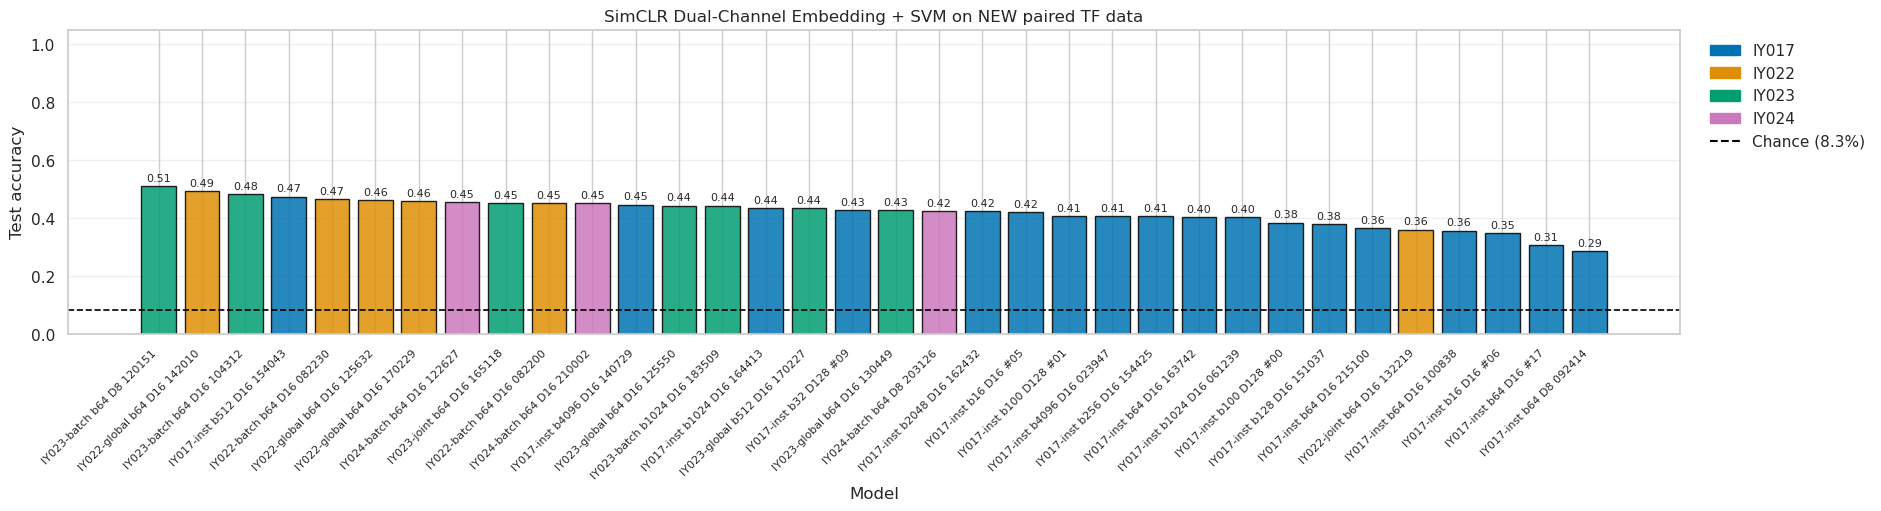

Best model: IY023-batch b64 D8 120151 (0.5098)
Checkpoint: IY023_simCLR_mixed_b64_lr0.01_L2_H4_D8_batch-wise_20260416_120151_model.pth
Chance: 0.0833


In [7]:
valid_results = results_df[results_df["status"] == "ok"].copy()
chance = 1 / len(class_names)
palette = sns.color_palette("colorblind")
color_map = {
    "EXP-26-IY017": palette[0],
    "EXP-26-IY022": palette[1],
    "EXP-26-IY023": palette[2],
    "EXP-26-IY024": palette[4],
}
bar_colors = [color_map.get(exp, palette[7]) for exp in valid_results["experiment"]]

fig, ax = plt.subplots(figsize=(max(14, len(valid_results) * 0.55), 5), constrained_layout=True)
bars = ax.bar(range(len(valid_results)), valid_results["accuracy"], color=bar_colors, alpha=0.85, edgecolor="black")
ax.axhline(chance, color="black", linestyle="--", linewidth=1.2, label=f"Chance ({chance:.1%})")
ax.set_xticks(range(len(valid_results)))
ax.set_xticklabels(valid_results["label"], rotation=45, ha="right", fontsize=8)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Model")
ax.set_ylabel("Test accuracy")
ax.set_title("SimCLR Dual-Channel Embedding + SVM on NEW paired TF data")
ax.grid(axis="y", alpha=0.3)
for bar, acc in zip(bars, valid_results["accuracy"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{acc:.2f}", ha="center", va="bottom", fontsize=8)

from matplotlib.patches import Patch
legend_handles = [
    Patch(color=palette[0], label="IY017"),
    Patch(color=palette[1], label="IY022"),
    Patch(color=palette[2], label="IY023"),
    Patch(color=palette[4], label="IY024"),
    plt.Line2D([0], [0], color="black", linestyle="--", label=f"Chance ({chance:.1%})"),
]
ax.legend(handles=legend_handles, bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)

fig_path = IY021_DIR / "IY021_simclr_svm_NEW_results.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved: {fig_path}")
plt.show()

best = valid_results.iloc[0]
print(f"Best model: {best['label']} ({best['accuracy']:.4f})")
print(f"Checkpoint: {best['checkpoint_name']}")
print(f"Chance: {chance:.4f}")

Saved: /home/ianyang/stochastic_simulations/experiments/EXP-26-IY021/IY021_simclr_svm_NEW_top_confusion_matrices.png


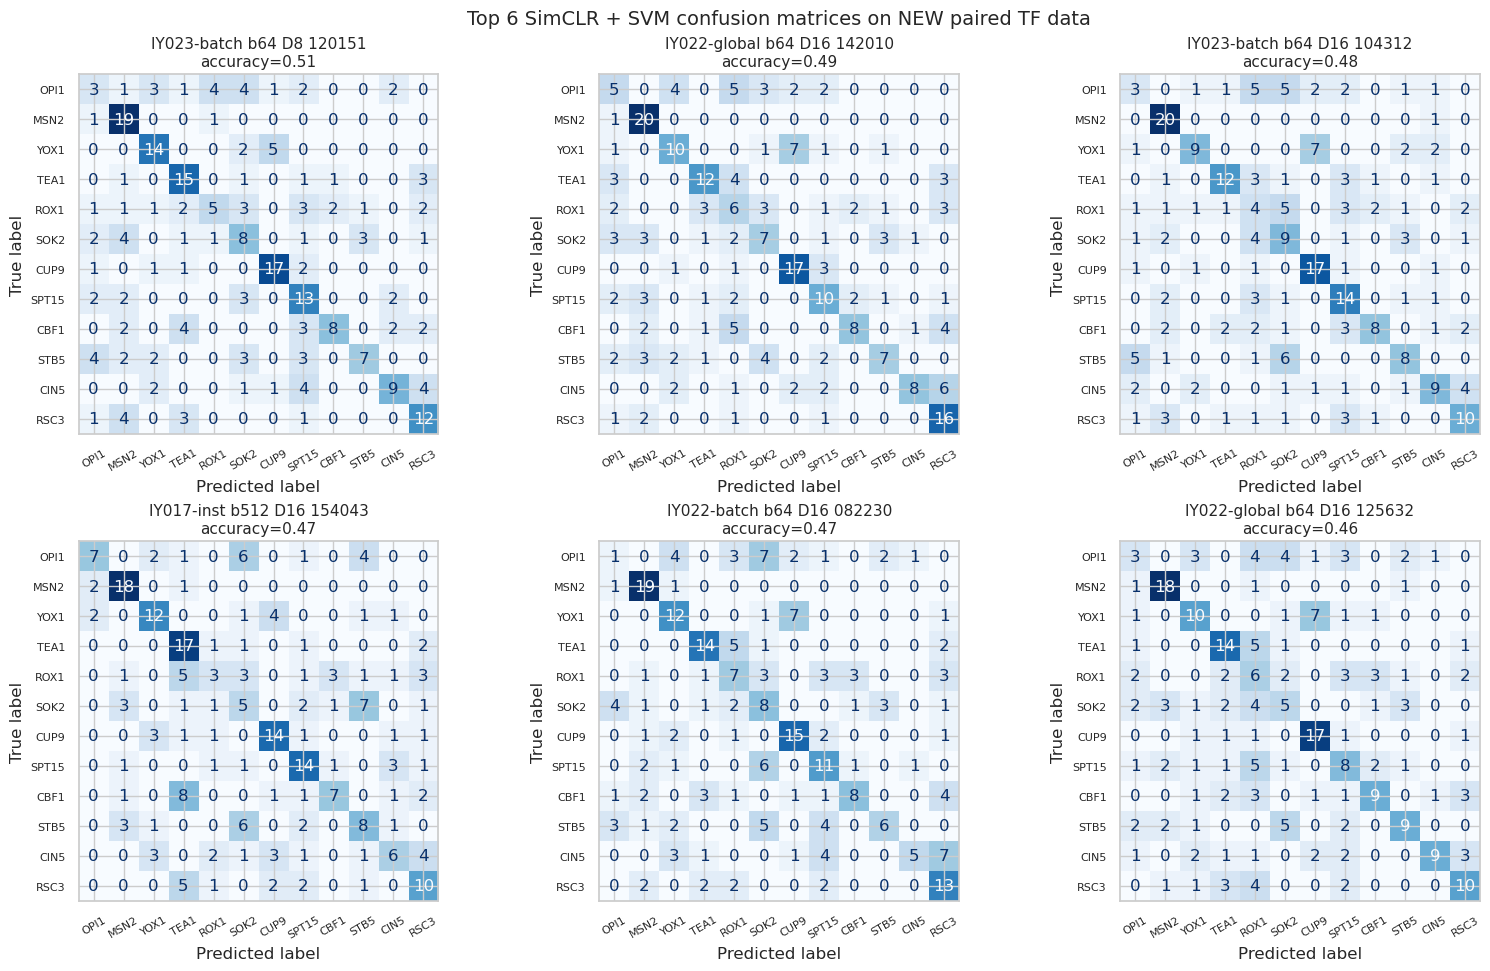

In [8]:
top_results = valid_results.head(TOP_N_CONFUSION)
ncols = min(3, len(top_results))
nrows = int(np.ceil(len(top_results) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 4.8 * nrows), constrained_layout=True)
axes = np.asarray(axes).reshape(-1)

for ax, (_, row) in zip(axes, top_results.iterrows()):
    y_pred = predictions[row["checkpoint"]]
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=class_names,
        ax=ax,
        colorbar=False,
        cmap="Blues",
        xticks_rotation=30,
    )
    ax.set_title(f"{row['label']}\naccuracy={row['accuracy']:.2f}", fontsize=11)
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)

for ax in axes[len(top_results):]:
    ax.axis("off")

fig.suptitle(f"Top {len(top_results)} SimCLR + SVM confusion matrices on NEW paired TF data", fontsize=14)
conf_path = IY021_DIR / "IY021_simclr_svm_NEW_top_confusion_matrices.png"
fig.savefig(conf_path, dpi=300, bbox_inches="tight")
print(f"Saved: {conf_path}")
plt.show()

## 6. Best Model Classification Report

In [9]:
best_checkpoint = valid_results.iloc[0]["checkpoint"]
best_pred = predictions[best_checkpoint]
print(classification_report(y_test, best_pred, target_names=class_names))

              precision    recall  f1-score   support

        OPI1       0.20      0.14      0.17        21
        MSN2       0.53      0.90      0.67        21
        YOX1       0.61      0.67      0.64        21
        TEA1       0.56      0.68      0.61        22
        ROX1       0.45      0.24      0.31        21
        SOK2       0.32      0.38      0.35        21
        CUP9       0.71      0.77      0.74        22
       SPT15       0.39      0.59      0.47        22
        CBF1       0.73      0.38      0.50        21
        STB5       0.64      0.33      0.44        21
        CIN5       0.60      0.43      0.50        21
        RSC3       0.50      0.57      0.53        21

    accuracy                           0.51       255
   macro avg       0.52      0.51      0.49       255
weighted avg       0.52      0.51      0.50       255

